In [1]:

import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd


In [7]:
import pandas as pd
import csv
import glob

archivos = glob.glob("C:/Users/Cristina/Documents/Entrenamiento-IA-/*.csv")
dataframes = {}
errores = []

for f in archivos:
    try:
        # Detectar delimitador automáticamente
        with open(f, 'r', encoding="latin1") as archivo:
            muestra = archivo.read(2048)  # primeras líneas
            dialecto = csv.Sniffer().sniff(muestra)
            sep_detectado = dialecto.delimiter
        
        print(f"Archivo: {f} → delimitador detectado: {sep_detectado}")
        
        # Leer con el separador correcto
        df = pd.read_csv(f, sep=sep_detectado, encoding="latin1", on_bad_lines="warn")
        dataframes[f] = df
    
    except Exception as e:
        print(f"⚠️ Error en {f}: {e}")
        errores.append(f)

# Unir todos los que se pudieron leer
df_final = pd.concat(dataframes.values(), ignore_index=True)




Archivo: C:/Users/Cristina/Documents/Entrenamiento-IA-\classData detection failure.csv → delimitador detectado: ,
Archivo: C:/Users/Cristina/Documents/Entrenamiento-IA-\classData1.csv → delimitador detectado: ,
Archivo: C:/Users/Cristina/Documents/Entrenamiento-IA-\CurrentVoltage1.csv → delimitador detectado: ,
Archivo: C:/Users/Cristina/Documents/Entrenamiento-IA-\detect_dataset1.csv → delimitador detectado: ,
Archivo: C:/Users/Cristina/Documents/Entrenamiento-IA-\Overview1.csv → delimitador detectado: ,


In [10]:
import pandas as pd
import glob

# Ruta de la carpeta con los CSV
ruta = "C:/Users/Cristina/Documents/Entrenamiento-IA-/*.csv"

# Buscar todos los archivos CSV en la carpeta
archivos = glob.glob(ruta)

# Leer y unir todos los CSV
df = pd.concat([pd.read_csv(f, encoding="latin1", sep=None, engine="python") for f in archivos],
               ignore_index=True)

# Mostrar dimensiones para confirmar
print("Filas y columnas:", df.shape)

# Opcional: ver todas las columnas en consola
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# Mostrar las primeras filas completas
print(df.head())


Filas y columnas: (67391, 31)
     G    C    B    A          Ia          Ib          Ic        Va        Vb  \
0  1.0  0.0  0.0  1.0 -151.291812   -9.677452   85.800162  0.400750 -0.132935   
1  1.0  0.0  0.0  1.0 -336.186183  -76.283262   18.328897  0.312732 -0.123633   
2  1.0  0.0  0.0  1.0 -502.891583 -174.648023  -80.924663  0.265728 -0.114301   
3  1.0  0.0  0.0  1.0 -593.941905 -217.703359 -124.891924  0.235511 -0.104940   
4  1.0  0.0  0.0  1.0 -643.663617 -224.159427 -132.282815  0.209537 -0.095554   

         Vc DeviceTimeStamp  VL1  VL2  VL3  IL1  IL2  IL3  VL12  VL23  VL31  \
0 -0.267815             NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN   NaN   NaN   
1 -0.189099             NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN   NaN   NaN   
2 -0.151428             NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN   NaN   NaN   
3 -0.130570             NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN   NaN   NaN   
4 -0.113983             NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN   NaN   NaN   

   INUT 

In [11]:
df.isnull().sum()

G                  51669
C                  51669
B                  51669
A                  51669
Ia                 39668
Ib                 39668
Ic                 39668
Va                 39668
Vb                 39668
Vc                 39668
DeviceTimeStamp    27723
VL1                48039
VL2                48039
VL3                48039
IL1                48039
IL2                48039
IL3                48039
VL12               48039
VL23               48039
VL31               48039
INUT               48039
Output (S)         55390
Unnamed: 7         67391
Unnamed: 8         67391
OTI                47075
WTI                47075
ATI                47075
OLI                47075
OTI_A              47075
OTI_T              47075
MOG_A              47075
dtype: int64

In [12]:
df. describe()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,VL1,VL2,VL3,IL1,IL2,IL3,VL12,VL23,VL31,INUT,Output (S),Unnamed: 7,Unnamed: 8,OTI,WTI,ATI,OLI,OTI_A,OTI_T,MOG_A
count,15722.000000,15722.000000,15722.000000,15722.000000,27723.000000,27723.000000,27723.000000,27723.000000,27723.000000,27723.000000,19352.000000,19352.000000,19352.000000,19352.000000,19352.000000,19352.000000,19352.00000,19352.000000,19352.000000,19352.000000,12001.000000,0.0,0.0,20316.000000,20316.000000,20316.000000,20316.000000,20316.000000,20316.000000,20316.000000
mean,0.432006,0.411271,0.555527,0.571429,10.685847,-36.928809,29.180683,0.000205,-0.006056,0.005851,241.068019,240.515456,239.912293,73.710857,58.970592,83.226555,379.47530,378.526261,379.969311,26.315187,0.457962,NaN,NaN,30.056064,0.270476,27.500541,70.953042,0.004971,0.002313,0.105976
std,0.495371,0.492080,0.496923,0.494887,429.025794,405.969043,342.964309,0.315245,0.333385,0.326442,9.536380,9.801129,8.846213,41.256800,40.463867,43.609360,119.96308,119.417113,120.074752,15.103268,0.498250,NaN,NaN,12.171179,0.444217,5.685277,27.635090,0.070335,0.048044,0.307814
min,0.000000,0.000000,0.000000,0.000000,-883.542316,-900.526951,-883.357762,-0.620748,-0.659921,-0.612709,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,36.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,-69.476762,-96.884566,-57.311948,-0.180424,-0.238105,-0.244645,235.400000,235.100000,235.100000,46.775000,31.500000,56.300000,400.70000,401.300000,401.900000,16.800000,0.000000,NaN,NaN,25.000000,0.000000,24.000000,41.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,1.000000,-0.915661,5.147734,-2.602645,-0.002626,-0.001462,0.009007,242.700000,242.100000,241.100000,69.500000,50.200000,80.200000,417.80000,416.300000,417.900000,25.600000,0.000000,NaN,NaN,29.000000,0.000000,28.000000,73.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,58.065061,80.232136,47.411186,0.192566,0.197752,0.262325,247.500000,246.700000,245.300000,100.100000,82.500000,113.900000,427.50000,425.300000,427.600000,35.700000,1.000000,NaN,NaN,34.000000,1.000000,31.000000,100.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,885.738571,889.868884,901.274261,0.609864,0.627875,0.608243,261.200000,261.300000,261.300000,224.100000,253.600000,247.300000,446.50000,444.800000,447.300000,145.800000,1.000000,NaN,NaN,250.000000,1.000000,44.000000,100.000000,1.000000,1.000000,1.000000


array([[<Axes: title={'center': 'G'}>, <Axes: title={'center': 'C'}>,
        <Axes: title={'center': 'B'}>, <Axes: title={'center': 'A'}>,
        <Axes: title={'center': 'Ia'}>],
       [<Axes: title={'center': 'Ib'}>, <Axes: title={'center': 'Ic'}>,
        <Axes: title={'center': 'Va'}>, <Axes: title={'center': 'Vb'}>,
        <Axes: title={'center': 'Vc'}>],
       [<Axes: title={'center': 'VL1'}>, <Axes: title={'center': 'VL2'}>,
        <Axes: title={'center': 'VL3'}>, <Axes: title={'center': 'IL1'}>,
        <Axes: title={'center': 'IL2'}>],
       [<Axes: title={'center': 'IL3'}>,
        <Axes: title={'center': 'VL12'}>,
        <Axes: title={'center': 'VL23'}>,
        <Axes: title={'center': 'VL31'}>,
        <Axes: title={'center': 'INUT'}>],
       [<Axes: title={'center': 'Output (S)'}>,
        <Axes: title={'center': 'Unnamed: 7'}>,
        <Axes: title={'center': 'Unnamed: 8'}>,
        <Axes: title={'center': 'OTI'}>, <Axes: title={'center': 'WTI'}>],
       [<Axes: 

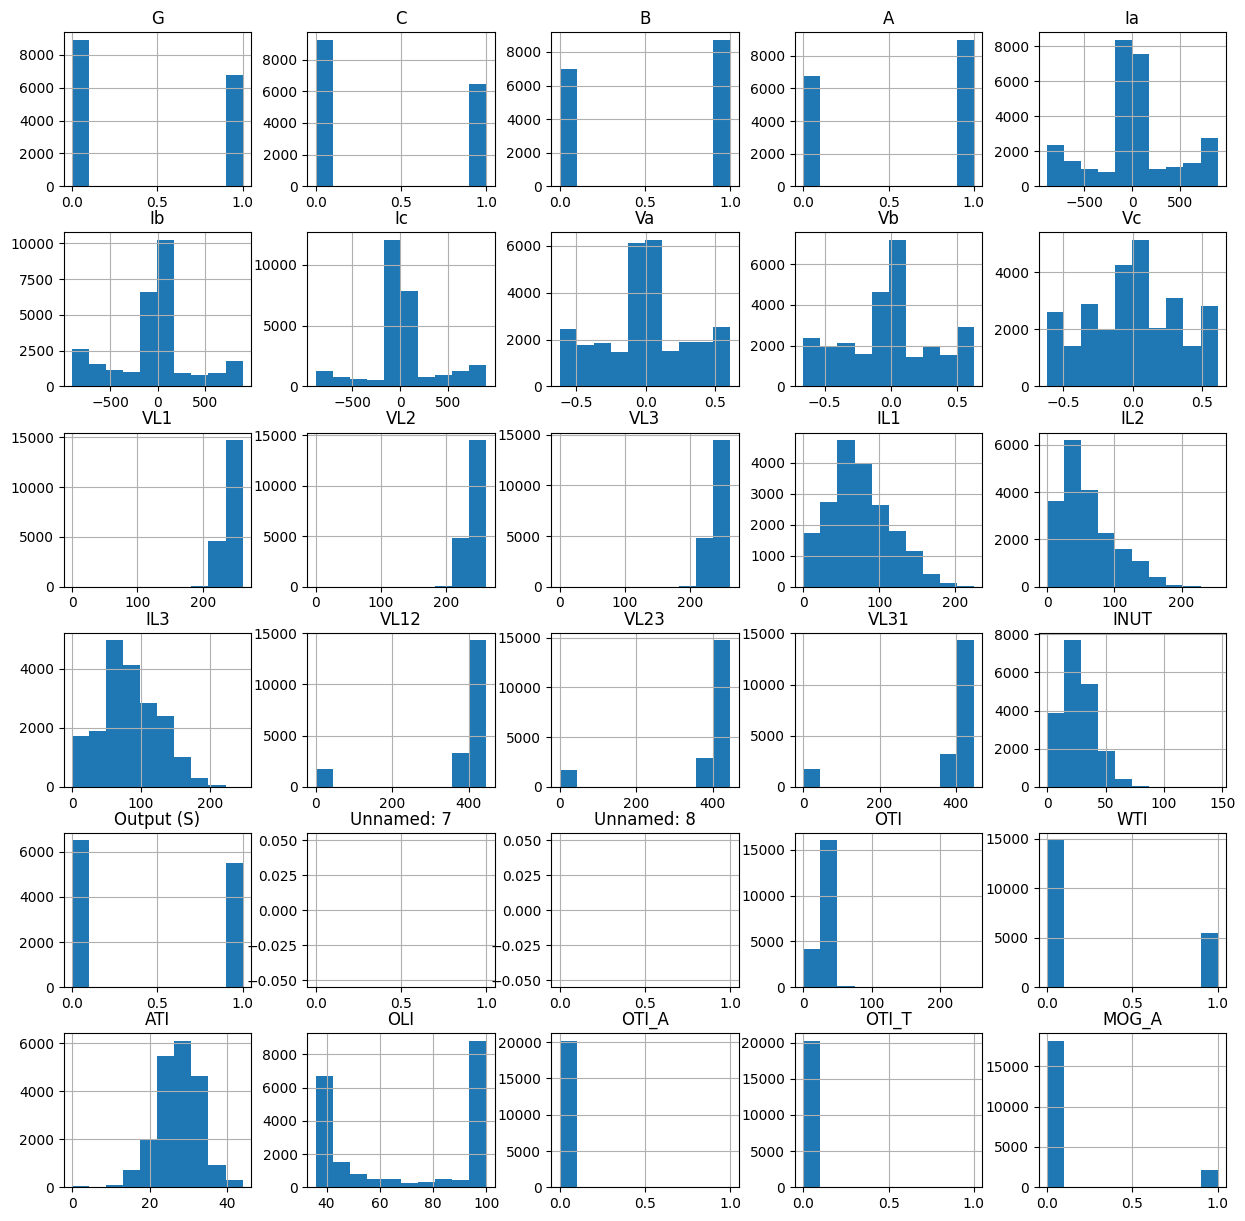

In [15]:
df.hist(figsize=(15,15))

In [17]:
print(df.columns.tolist())

['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc', 'DeviceTimeStamp', 'VL1', 'VL2', 'VL3', 'IL1', 'IL2', 'IL3', 'VL12', 'VL23', 'VL31', 'INUT', 'Output (S)', 'Unnamed: 7', 'Unnamed: 8', 'OTI', 'WTI', 'ATI', 'OLI', 'OTI_A', 'OTI_T', 'MOG_A']


In [21]:
# Conteo de ocurrencias por clase
conteo = df["Output (S)"].value_counts()
print(conteo)

# Porcentajes relativos
porcentajes = df["Output (S)"].value_counts(normalize=True) * 100
print(porcentajes)


Output (S)
0.0    6505
1.0    5496
Name: count, dtype: int64
Output (S)
0.0    54.203816
1.0    45.796184
Name: proportion, dtype: float64


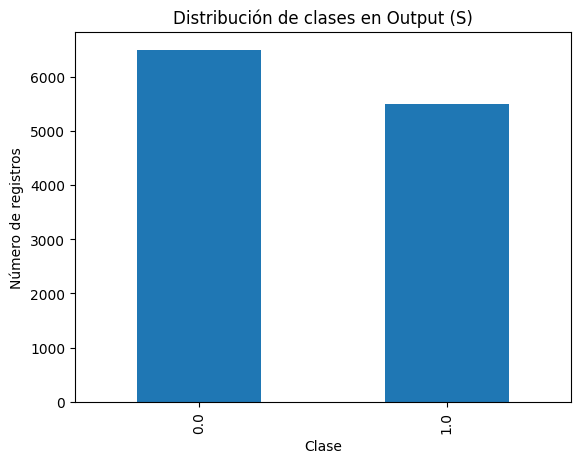

In [22]:
import matplotlib.pyplot as plt

df["Output (S)"].value_counts().plot(kind="bar")
plt.title("Distribución de clases en Output (S)")
plt.xlabel("Clase")
plt.ylabel("Número de registros")
plt.show()


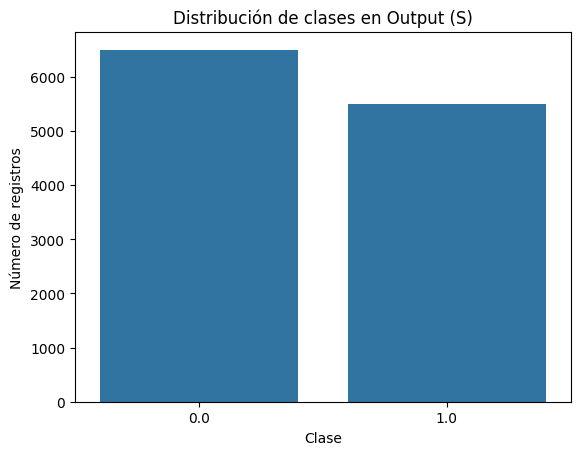

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Output (S)", data=df)
plt.title("Distribución de clases en Output (S)")
plt.xlabel("Clase")
plt.ylabel("Número de registros")
plt.show()


<Axes: xlabel='Output (S)', ylabel='count'>

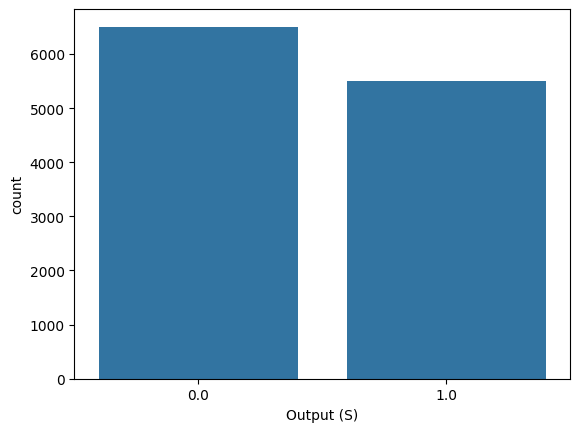

In [24]:
sns.countplot(x="Output (S)", data=df.dropna(subset=["Output (S)"]))

In [25]:
df.columns

Index(['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc',
       'DeviceTimeStamp', 'VL1', 'VL2', 'VL3', 'IL1', 'IL2', 'IL3', 'VL12',
       'VL23', 'VL31', 'INUT', 'Output (S)', 'Unnamed: 7', 'Unnamed: 8', 'OTI',
       'WTI', 'ATI', 'OLI', 'OTI_A', 'OTI_T', 'MOG_A'],
      dtype='str')

In [29]:
#aplicar columna en el eje X
def classify_failure_type(row):
    if row["Output (S)"] == 1:
        return "Fallo detectado"
    else:
        return "Sin fallo"

df["Failure Type"] =df.apply(classify_failure_type, axis=1)


In [30]:
#veriricar 
df["Failure Type"]

0              Sin fallo
1              Sin fallo
2              Sin fallo
3              Sin fallo
4              Sin fallo
5              Sin fallo
6              Sin fallo
7              Sin fallo
8              Sin fallo
9              Sin fallo
10             Sin fallo
11             Sin fallo
12             Sin fallo
13             Sin fallo
14             Sin fallo
15             Sin fallo
16             Sin fallo
17             Sin fallo
18             Sin fallo
19             Sin fallo
20             Sin fallo
21             Sin fallo
22             Sin fallo
23             Sin fallo
24             Sin fallo
25             Sin fallo
26             Sin fallo
27             Sin fallo
28             Sin fallo
29             Sin fallo
30             Sin fallo
31             Sin fallo
32             Sin fallo
33             Sin fallo
34             Sin fallo
35             Sin fallo
36             Sin fallo
37             Sin fallo
38             Sin fallo
39             Sin fallo


<Axes: xlabel='Failure Type', ylabel='count'>

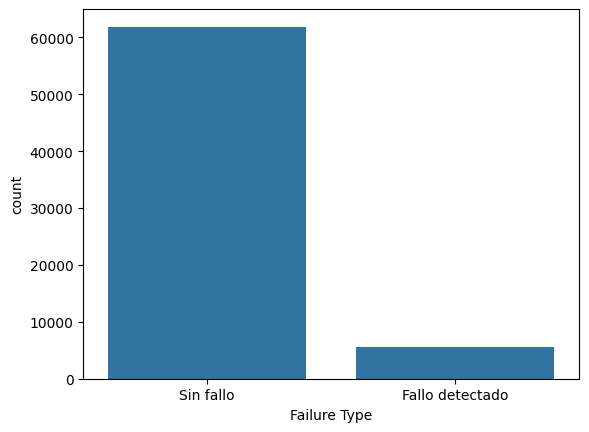

In [31]:
#trazado de cuentas 
sns.countplot(x="Failure Type", data=df)

In [33]:
print(df.columns.tolist())

['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc', 'DeviceTimeStamp', 'VL1', 'VL2', 'VL3', 'IL1', 'IL2', 'IL3', 'VL12', 'VL23', 'VL31', 'INUT', 'Output (S)', 'Unnamed: 7', 'Unnamed: 8', 'OTI', 'WTI', 'ATI', 'OLI', 'OTI_A', 'OTI_T', 'MOG_A', 'Failure Type']


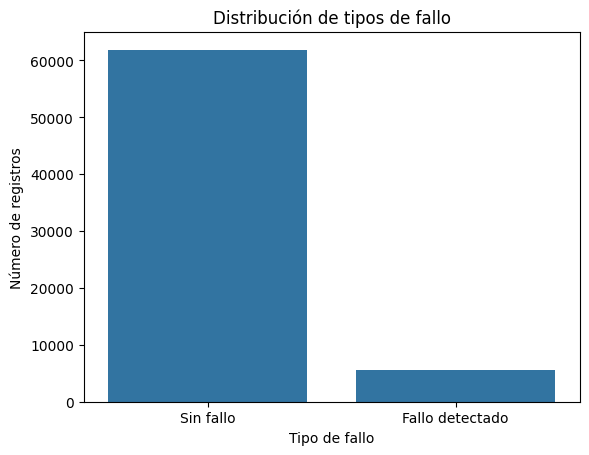

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Failure Type", data=df)
plt.title("Distribución de tipos de fallo")
plt.xlabel("Tipo de fallo")
plt.ylabel("Número de registros")
plt.show()


### volver acá para corregir  el mapeo de errores 

In [40]:
from sklearn.utils import resample

# separar clases
df_majority = df[df["Failure Type"] == "No Failure"]
df_minority = df[df["Failure Type"] != "No Failure"]

# sobremuestrear minoritarias hasta igualar la mayoritaria
df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

# combinar
df_balanced = pd.concat([df_majority, df_minority_upsampled])


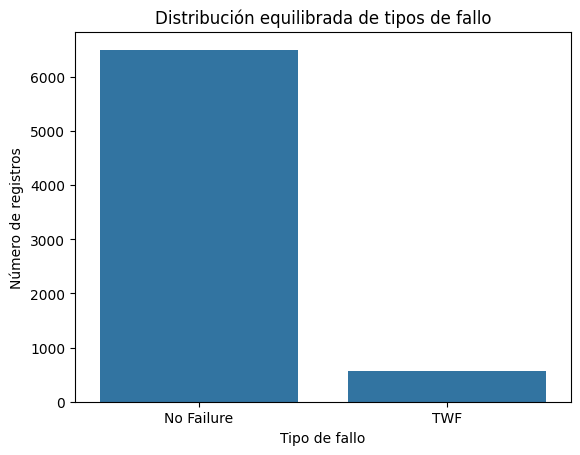

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Failure Type", data=df_balanced)
plt.title("Distribución equilibrada de tipos de fallo")
plt.xlabel("Tipo de fallo")
plt.ylabel("Número de registros")
plt.show()


In [42]:
df_balanced = pd.concat([df_majority, df_minority_upsampled]).reset_index(drop=True)


In [44]:
print(df["Output (S)"].unique())


[nan  0.  1.]


In [45]:
def classify_failure_type(value):
    return "Failure" if value == 1 else "No Failure"

df["Failure Type"] = df["Output (S)"].apply(classify_failure_type)


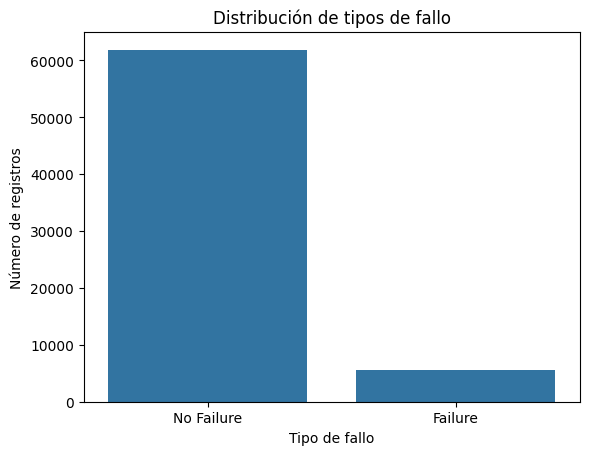

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Failure Type", data=df)
plt.title("Distribución de tipos de fallo")
plt.xlabel("Tipo de fallo")
plt.ylabel("Número de registros")
plt.show()


In [47]:
failure_cols = ["Output (S)"]

def classify_failure_type(row):
    for col in failure_cols:
        if row[col] == 1:
            return col   # devuelve exactamente el nombre de la falla
    return "No Failure"  # usa la misma etiqueta que el dataset original

df ["Failure Type"] = df.apply(classify_failure_type, axis=1)

### usamos voltajes y corrientes 

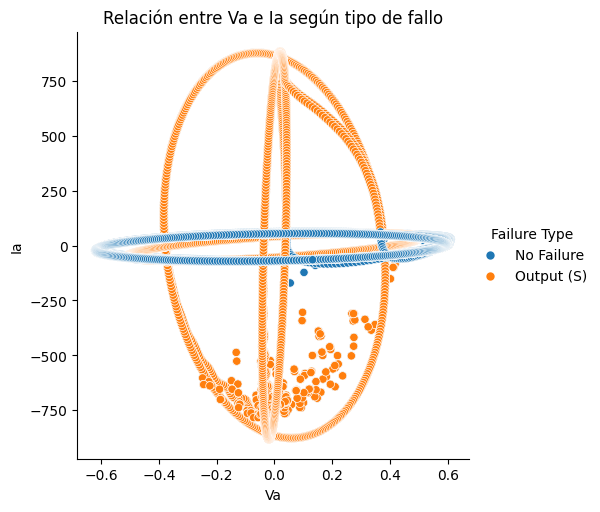

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(
    x="Va", 
    y="Ia", 
    hue="Failure Type",   # colorea según el tipo de fallo
    kind="scatter",
    data=df
)
plt.title("Relación entre Va e Ia según tipo de fallo")
plt.show()


### temperaturas internas del transformador 

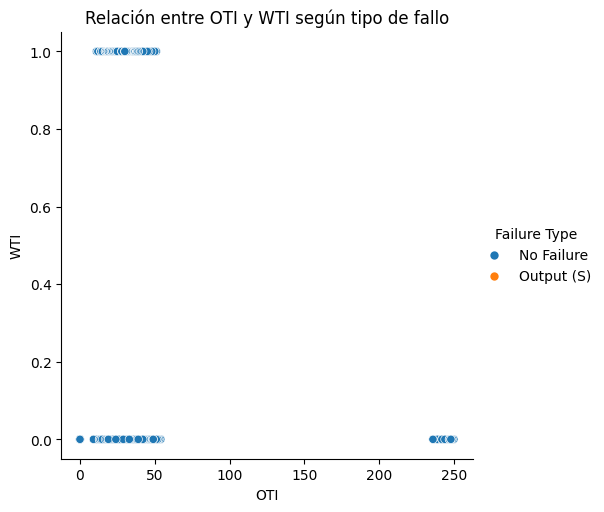

In [50]:
sns.relplot(
    x="OTI", 
    y="WTI", 
    hue="Failure Type",
    kind="scatter",
    data=df
)
plt.title("Relación entre OTI y WTI según tipo de fallo")
plt.show()

In [51]:
df["Failure Type"].unique()

<StringArray>
['No Failure', 'Output (S)']
Length: 2, dtype: str

### vamos a tener que crear la lista de armonicos 2º,3º,5º,7º,13º con la Transformada rapida de Fourier  

In [52]:
signal_cols = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
df[signal_cols] = df[signal_cols].apply(pd.to_numeric, errors='coerce')


In [53]:
import numpy as np
from scipy.fft import fft

def calcular_armonicos(signal, armonicos, fs=1000):
    """
    signal: serie temporal de la señal
    armonicos: lista de armónicos a calcular (ej. [2,3,5,7,13])
    fs: frecuencia de muestreo (ajusta según tu dataset)
    """
    N = len(signal)
    yf = fft(signal)
    xf = np.fft.fftfreq(N, 1/fs)
    
    magnitudes = {}
    for h in armonicos:
        freq = h * (fs / N)  # frecuencia del armónico
        idx = (np.abs(xf - freq)).argmin()
        magnitudes[f"H{h}"] = np.abs(yf[idx])
    return magnitudes


In [54]:
armonicos = [2, 3, 5, 7, 13]

# ejemplo con Ia
df_harmonics = df.apply(lambda row: calcular_armonicos(
    [row[col] for col in signal_cols], armonicos), axis=1)

# convertir dict a DataFrame y unir
harmonics_df = pd.DataFrame(df_harmonics.tolist())
df = pd.concat([df, harmonics_df], axis=1)


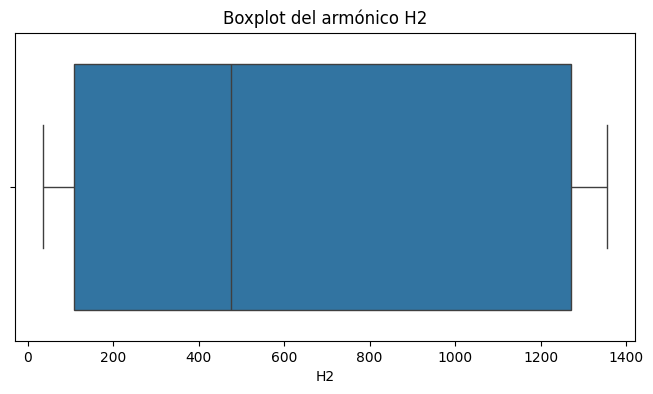

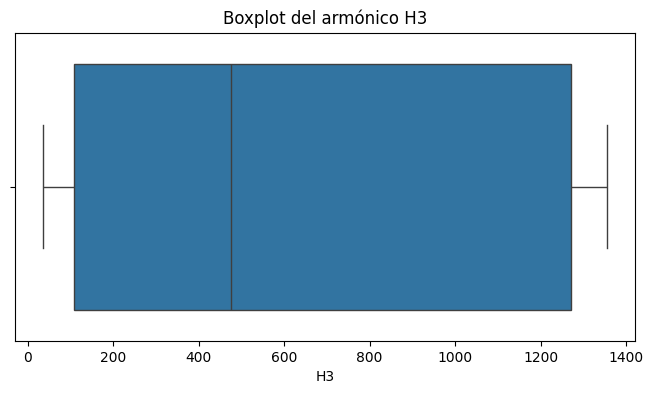

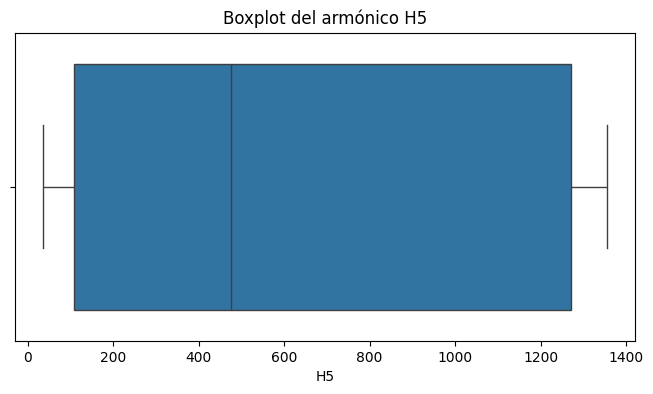

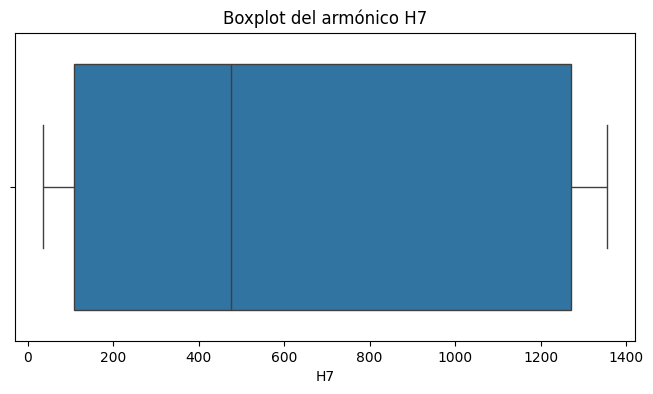

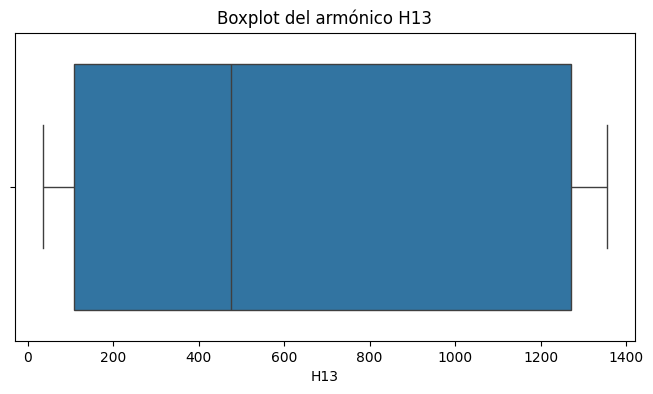

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

harmonic_cols = ['H2', 'H3', 'H5', 'H7', 'H13']

for col in harmonic_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot del armónico {col}')
    plt.show()


### detectar falla  perdida de una fase en el transformador

In [56]:
def detectar_perdida_fase(row, columnas, umbral=0.2):
    """
    row: fila del DataFrame
    columnas: lista de columnas de las fases (ej. ['Ia','Ib','Ic'])
    umbral: porcentaje mínimo aceptable respecto al promedio
    """
    valores = [row[col] for col in columnas]
    promedio = np.mean(valores)
    
    for i, val in enumerate(valores):
        if promedio > 0 and val < umbral * promedio:
            return f"Pérdida de fase en {columnas[i]}"
    return "Normal"

# Detectar pérdida de fase en corrientes
df["Phase Failure Current"] = df.apply(lambda row: detectar_perdida_fase(row, ["Ia","Ib","Ic"]), axis=1)

# Detectar pérdida de fase en voltajes
df["Phase Failure Voltage"] = df.apply(lambda row: detectar_perdida_fase(row, ["Va","Vb","Vc"]), axis=1)


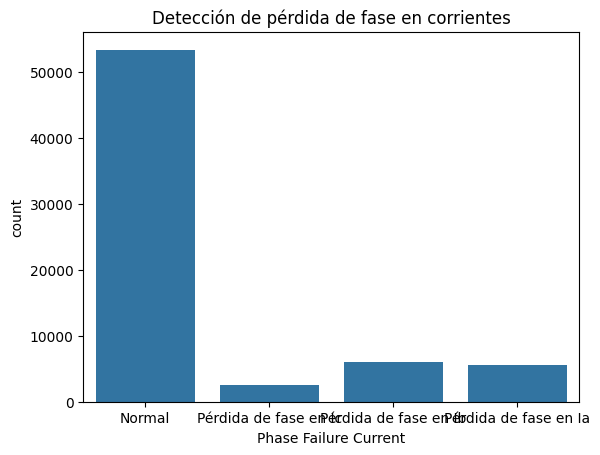

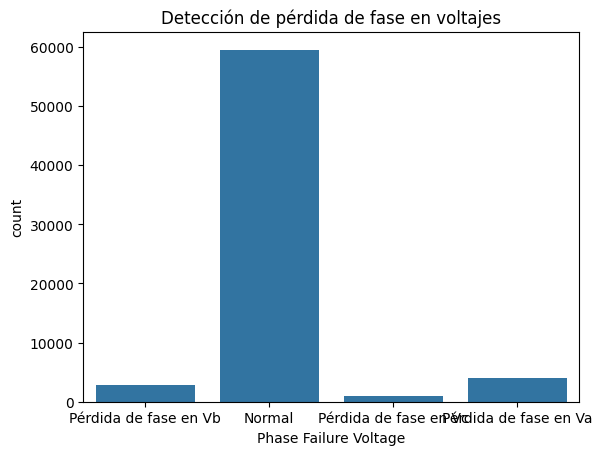

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Phase Failure Current", data=df)
plt.title("Detección de pérdida de fase en corrientes")
plt.show()

sns.countplot(x="Phase Failure Voltage", data=df)
plt.title("Detección de pérdida de fase en voltajes")
plt.show()


### se deriva una descarga monofasica a tierra 

In [58]:
import numpy as np

def detectar_descarga_monofasica(row, columnas, umbral_sobre=1.2, umbral_bajo=0.8):
    """
    row: fila del DataFrame
    columnas: ['Va','Vb','Vc']
    umbral_sobre: factor de sobretensión respecto al promedio
    umbral_bajo: factor de caída respecto al promedio
    """
    valores = [row[col] for col in columnas]
    promedio = np.mean(valores)
    
    # condiciones de sobretensión y caída
    sobre = [val > umbral_sobre * promedio for val in valores]
    bajo  = [val < umbral_bajo * promedio for val in valores]
    
    # si dos fases están en sobre y una en bajo → descarga monofásica
    if sum(sobre) == 2 and sum(bajo) == 1:
        return "Descarga monofásica transitoria"
    return "Normal"

# aplicar sobre tensiones
df["Phase-to-Ground Event"] = df.apply(lambda row: detectar_descarga_monofasica(row, ["Va","Vb","Vc"]), axis=1)


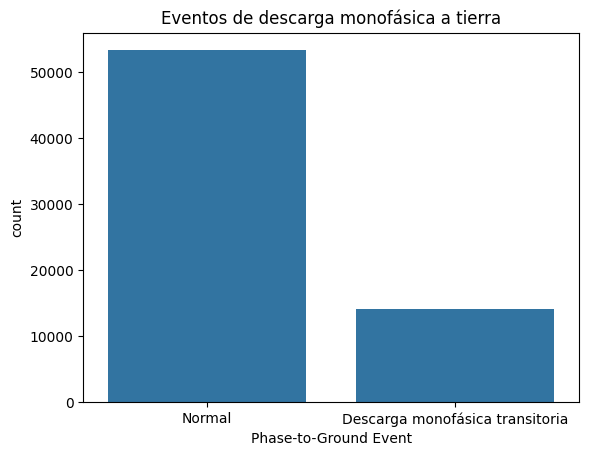

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Phase-to-Ground Event", data=df)
plt.title("Eventos de descarga monofásica a tierra")
plt.show()


In [60]:
df.columns 

Index(['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc',
       'DeviceTimeStamp', 'VL1', 'VL2', 'VL3', 'IL1', 'IL2', 'IL3', 'VL12',
       'VL23', 'VL31', 'INUT', 'Output (S)', 'Unnamed: 7', 'Unnamed: 8', 'OTI',
       'WTI', 'ATI', 'OLI', 'OTI_A', 'OTI_T', 'MOG_A', 'Failure Type', 'H2',
       'H3', 'H5', 'H7', 'H13', 'Phase Failure Current',
       'Phase Failure Voltage', 'Phase-to-Ground Event'],
      dtype='str')

In [63]:
df['FailureType_num'] = df['Failure Type'].map({
    "No Failure": 0,
    "TWF": 1,
    "HDF": 2,
    "PWF": 3,
    "OSF": 4,
    "RNF": 5
})


In [64]:
df['PhaseGround_num'] = df['Phase-to-Ground Event'].map({
    "Normal": 0,
    "Descarga monofásica transitoria": 1
})


In [65]:
df['PhaseFailCurrent_num'] = df['Phase Failure Current'].map({
    "Normal": 0,
    "Pérdida de fase en Ia": 1,
    "Pérdida de fase en Ib": 2,
    "Pérdida de fase en Ic": 3
})


In [66]:
# Cargar paquetes de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [ ]:
ylabels = df["Failure Type"]   # o df["Output (S)"]  prefiero los códigos


In [68]:
feature_cols = ["Ia", "Ib", "Ic", "Va", "Vb", "Vc", "OTI", "WTI", "ATI"]
Xfeatures = df[feature_cols]


In [69]:
df["FailureType_num"] = df["Failure Type"].map({
    "No Failure": 0,
    "TWF": 1,
    "HDF": 2,
    "PWF": 3,
    "OSF": 4,
    "RNF": 5
})

ylabels = df["FailureType_num"]


In [71]:
print(df["Failure Type"].isna().sum())


0


In [72]:
print(df["FailureType_num"].isna().sum())


5496


In [73]:
df_clean = df.dropna(subset=["FailureType_num"])


In [74]:
feature_cols = ["Ia", "Ib", "Ic", "Va", "Vb", "Vc", "OTI", "WTI", "ATI"]
Xfeatures = df_clean[feature_cols]
ylabels = df_clean["FailureType_num"]


In [75]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    Xfeatures, ylabels, test_size=0.25, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Accuracy:", rf.score(X_test, y_test))


Accuracy: 1.0


### esta muy perfecto el resultado esto es raro...

In [76]:
print(feature_cols)


['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc', 'OTI', 'WTI', 'ATI']


In [77]:
print(ylabels.value_counts())


FailureType_num
0.0    61895
Name: count, dtype: int64


In [78]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15474

    accuracy                           1.00     15474
   macro avg       1.00      1.00      1.00     15474
weighted avg       1.00      1.00      1.00     15474



In [79]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, Xfeatures, ylabels, cv=5)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())


Cross-validation scores: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0


In [80]:
print(feature_cols)


['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc', 'OTI', 'WTI', 'ATI']


In [81]:
import pandas as pd

importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print(feat_imp)


Ia     0.0
Ib     0.0
Ic     0.0
Va     0.0
Vb     0.0
Vc     0.0
OTI    0.0
WTI    0.0
ATI    0.0
dtype: float64


In [82]:
print(Xfeatures.head())
print(Xfeatures.isna().sum())


           Ia          Ib          Ic        Va        Vb        Vc  OTI  WTI  \
0 -151.291812   -9.677452   85.800162  0.400750 -0.132935 -0.267815  NaN  NaN   
1 -336.186183  -76.283262   18.328897  0.312732 -0.123633 -0.189099  NaN  NaN   
2 -502.891583 -174.648023  -80.924663  0.265728 -0.114301 -0.151428  NaN  NaN   
3 -593.941905 -217.703359 -124.891924  0.235511 -0.104940 -0.130570  NaN  NaN   
4 -643.663617 -224.159427 -132.282815  0.209537 -0.095554 -0.113983  NaN  NaN   

   ATI  
0  NaN  
1  NaN  
2  NaN  
3  NaN  
4  NaN  
Ia     39668
Ib     39668
Ic     39668
Va     39668
Vb     39668
Vc     39668
OTI    41579
WTI    41579
ATI    41579
dtype: int64


In [85]:
df_clean = df.dropna(subset=feature_cols)


In [86]:
print(df[feature_cols].isna().sum())


Ia     39668
Ib     39668
Ic     39668
Va     39668
Vb     39668
Vc     39668
OTI    47075
WTI    47075
ATI    47075
dtype: int64


In [87]:
df_clean = df.dropna(subset=feature_cols)


In [88]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")  # o "median"
Xfeatures = imputer.fit_transform(df[feature_cols])


In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xfeatures = scaler.fit_transform(Xfeatures)


In [91]:
feature_cols = ["Ia", "Ib", "Ic", "Va", "Vb", "Vc", "OTI", "WTI", "ATI"]

# Eliminar filas con NaN en features o en la etiqueta
df_clean = df.dropna(subset=feature_cols + ["FailureType_num"])

# Definir X y y alineados
Xfeatures = df_clean[feature_cols].astype(float)
ylabels = df_clean["FailureType_num"].astype(int)

print("Tamaño X:", Xfeatures.shape)
print("Tamaño y:", ylabels.shape)


Tamaño X: (0, 9)
Tamaño y: (0,)


In [93]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

feature_cols = ["Ia", "Ib", "Ic", "Va", "Vb", "Vc", "OTI", "WTI", "ATI"]

# Imputar NaN con la media de cada columna
imputer = SimpleImputer(strategy="mean")
Xfeatures = imputer.fit_transform(df[feature_cols])

# Etiquetas (asegúrate de que estén codificadas)
ylabels = df["FailureType_num"]

# Eliminar filas donde la etiqueta sea NaN
mask = ylabels.notna()
Xfeatures = Xfeatures[mask]
ylabels = ylabels[mask]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    Xfeatures, ylabels, test_size=0.25, random_state=42
)

# Entrenar modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Accuracy:", rf.score(X_test, y_test))
print("Importancias:", rf.feature_importances_)


Accuracy: 1.0
Importancias: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
